In [134]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns

In [135]:
df=pd.read_csv('headlines.csv',names=['text'])

In [136]:
print(df['text'][0])

Budget to set scene for election
 
 Gordon Brown will seek to put the economy at the centre of Labour's bid for a third term in power when he delivers his ninth Budget at 1230 GMT. He is expected to stress the importance of continued economic stability, with low unemployment and interest rates. The chancellor is expected to freeze petrol duty and raise the stamp duty threshold from Â£60,000. But the Conservatives and Lib Dems insist voters face higher taxes and more means-testing under Labour.
 
 Treasury officials have said there will not be a pre-election giveaway, but Mr Brown is thought to have about Â£2bn to spare.
 
 - Increase in the stamp duty threshold from Â£60,000 
  - A freeze on petrol duty 
  - An extension of tax credit scheme for poorer families 
  - Possible help for pensioners The stamp duty threshold rise is intended to help first time buyers - a likely theme of all three of the main parties' general election manifestos. Ten years ago, buyers had a much greater chanc

#### Data Preprocessing

In [137]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer

In [138]:
sWords=stopwords.words('english')

In [139]:
def clean_text(sent):
    tokens1=word_tokenize(sent)
    tokens2=[token for token in tokens1 if token.isalpha()]
    tokens3=[token.lower() for token in tokens2 if token.lower() not in sWords]
    return tokens3

In [140]:
sent='The raning was expected today. But  not completed'

In [141]:
clean_sent=clean_text(sent)

In [142]:
wnl=WordNetLemmatizer()
wnl.lemmatize('excepted',pos='v')

'except'

In [143]:
def mylemmatize(word):
    tag=pos_tag([word])
    if tag[0][1].startswith('V'):
        return wnl.lemmatize(word,pos='v')
    if tag[0][1].startswith('N'):
        return wnl.lemmatize(word,pos='n')
    if tag[0][1].startswith('J'):
        return wnl.lemmatize(word,pos='a')
    if tag[0][1].startswith('R'):
        return wnl.lemmatize(word,pos='r')
    return word


In [144]:
lems

['raning', 'expect', 'today', 'complete']

In [145]:
# add lemmatize in function also
def clean_text(sent):
    tokens1=word_tokenize(sent)
    tokens2=[token for token in tokens1 if token.isalpha()]
    tokens3=[mylemmatize(token.lower()) for token in tokens2 if token.lower() not in sWords]
    return tokens3

In [146]:
print(clean_text(sent))

['raning', 'expect', 'today', 'complete']


#### Vectorize data

In [147]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [148]:
tfidf=TfidfVectorizer(analyzer=clean_text)

In [149]:
x_new=tfidf.fit_transform(df['text'])

In [150]:
x_new

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 310708 stored elements and shape (2225, 21406)>

In [151]:
x_new.shape

(2225, 21406)

In [152]:
from wordcloud import WordCloud

In [158]:
final_text=df['text'].apply(clean_text).sum()


In [159]:
final_text=' '.join(final_text)

In [163]:
wCloud=WordCloud(max_words=100,background_color='white').generate(final_text)

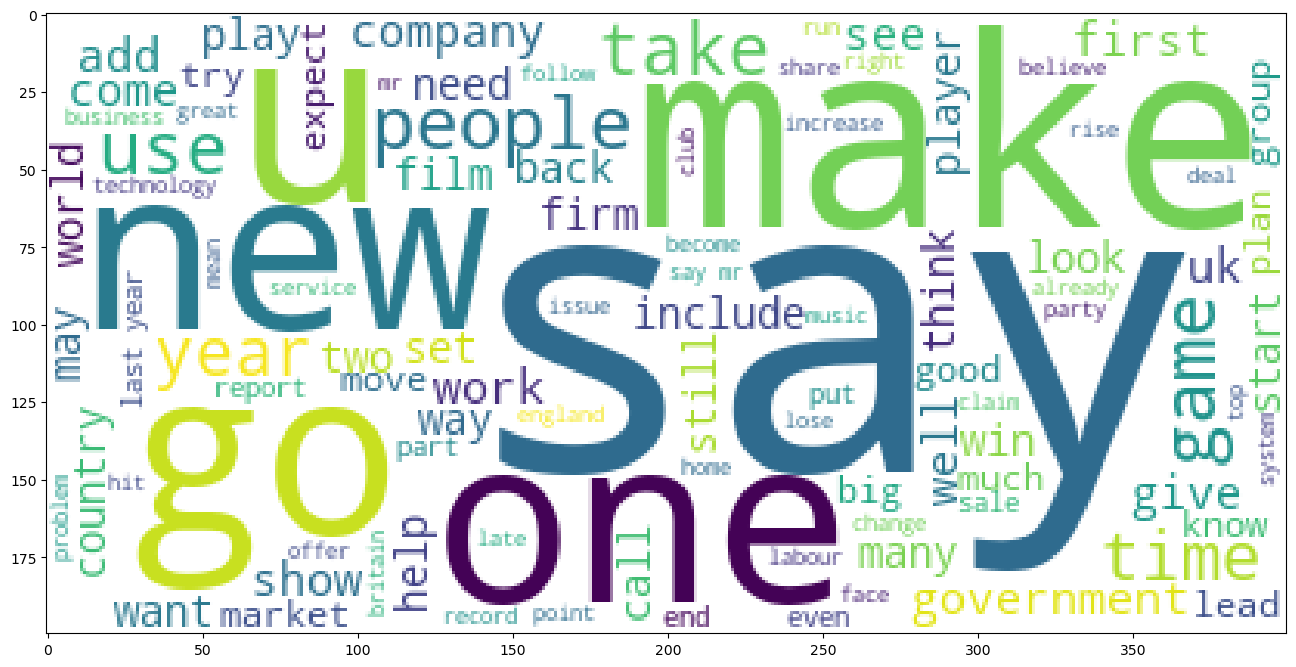

In [164]:
plt.figure(figsize=(16,9))
plt.imshow(wCloud)

In [165]:
# delete these common words from all news

In [166]:
sWords.extend(['say','said','saying','make','made','one','u','new','go','gone','went'])

In [167]:
def clean_text(sent):
    tokens1=word_tokenize(sent)
    tokens2=[token for token in tokens1 if token.isalpha()]
    tokens3=[mylemmatize(token.lower()) for token in tokens2 if token.lower() not in sWords]
    return tokens3

In [168]:
tfidf = TfidfVectorizer(analyzer=clean_text)
x_new=tfidf.fit_transform(df['text'])

In [169]:
x_new

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 305916 stored elements and shape (2225, 21405)>

In [170]:
x_new.shape

(2225, 21405)

##### identify the no of clustors

In [175]:
from sklearn.cluster import KMeans

In [179]:
km=KMeans(n_clusters=10,n_init='auto')

In [180]:
km.fit(x_new)

,n_clusters,10
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [181]:
km.inertia_

2056.627233959763

In [195]:
sse=[]
for k in range(1,16):
    km=KMeans(n_clusters=k,n_init='auto', random_state=0)
    km.fit(x_new)
    sse.append(km.inertia_)

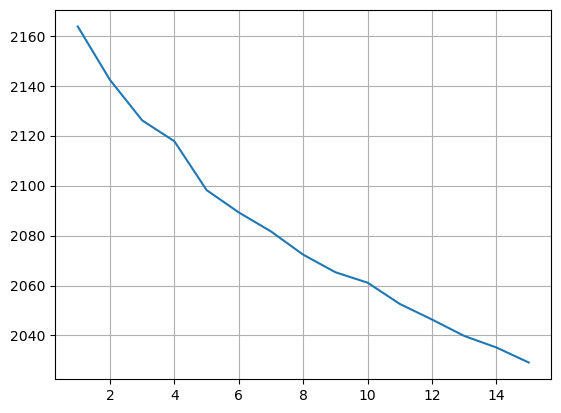

In [196]:
plt.plot(range(1,16),sse)
plt.grid()

In [201]:
%pip install kneed

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [198]:
from kneed import KneeLocator

In [199]:
kl = KneeLocator(range(1,16),sse,curve='convex',direction='decreasing')

In [200]:
kl.elbow

np.int64(5)

In [202]:
km= KMeans(n_clusters=5,n_init='auto',random_state=0)

In [203]:
labels=km.fit_predict(x_new)

In [204]:
labels

array([4, 3, 4, ..., 3, 3, 3], dtype=int32)

In [209]:
zero=df['text'][labels==0]
one=df['text'][labels==1]
two=df['text'][labels==2]
three=df['text'][labels==3]
four=df['text'][labels==4]


In [ ]:
zero.shape,one.shape,two.shape,three.shape,four.shape,

((376,), (355,), (517,), (693,), (284,))

In [212]:
zero= " " .join(zero.apply(clean_text).sum())

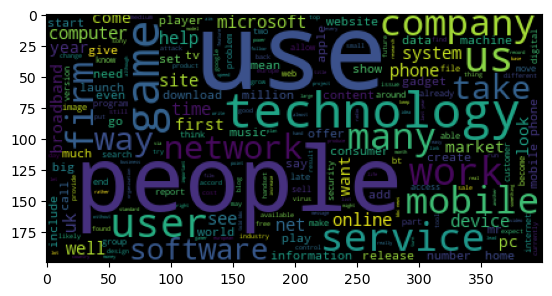

In [214]:
zero_wcloud=WordCloud().generate(zero)
plt.imshow(zero_wcloud)

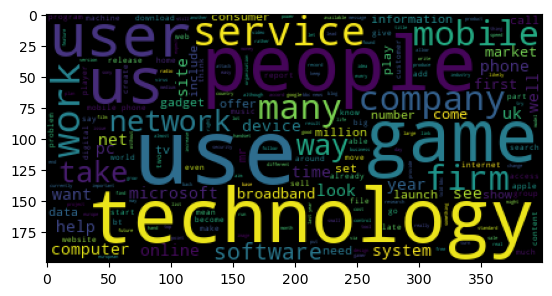

In [ ]:
one= " " .join(one.apply(clean_text).sum())
one_wcloud=WordCloud().generate(one)
plt.imshow(one_wcloud)

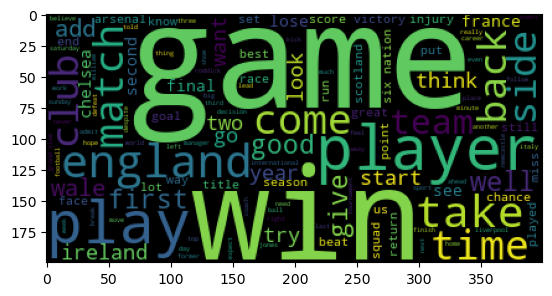

In [218]:
two= " " .join(two.apply(clean_text).sum())
two_wcloud=WordCloud().generate(two)
plt.imshow(two_wcloud)

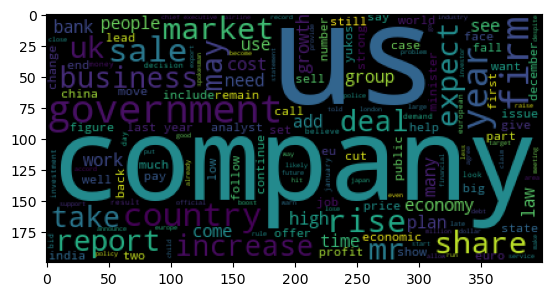

In [219]:
three= " " .join(three.apply(clean_text).sum())
three_wcloud=WordCloud().generate(three)
plt.imshow(three_wcloud)

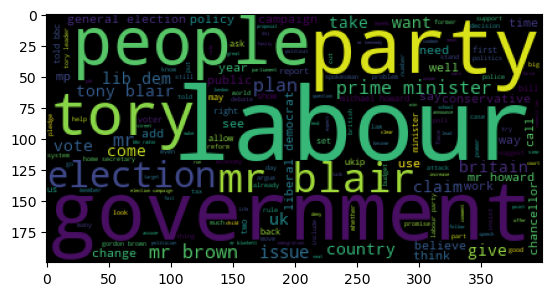

In [220]:
four= " " .join(four.apply(clean_text).sum())
four_wcloud=WordCloud().generate(four)
plt.imshow(four_wcloud)

#### new news perdiction

In [221]:
new_news='''IND vs AFG: The bowler who scored the Ranji Trophy finally got an entry into Team India's fleet! Big decision before the Test against Afghanistan
Auqib Nabi Drafted into Team India: The Indian team wants to play a Test match against Afghanistan from June. Jammu-Kashmir's bowler has entered the Indian team for the match.'''

In [224]:
x_new=tfidf.transform([new_news])

In [226]:
km.predict(x_new)

array([2], dtype=int32)

In [232]:
new_news='''Food Adulteration Raid: Big bump as soon as you charge Tukaram Mustam! Seize 4.72 lakh incinerated food in Nagpur; On the 'FDA' action mode, the threads of the beggars
Major FDA Crackdown in Nagpur Under Tukaram Mandhe: IAS Officer Tukaram Mundhe took major action in Nagpur after accepting the FDA Commissioner. Nagpur : Containing court in administration IAS Officer Tukaram Mundhe (IAS official Tukaram Mundhe) recently took over as commissioner in the Department of Food and Drug Administration. In addition, this section has been ‘Flowercharge ’ and Chapter Action is underway across the state. The Nagpur district has also seized a stockpile of about 2.2 million foods suspected of adulteration in various places.

According to information provided by the Food and Drug Administration, the action seized about 1,000 1,000,000,000 turmeric and chili powder. In addition, ⁇ 1,000 1,000 liters of package drinking water worth Rs. 1,000, 1,000, 1,000,000 rupees worth ⁇ kg paneer and उपल्प 2,000 per 1,000 per 1,000 other food samples were also confiscated for inspection. The total cost of the confiscated stock is Rs 2,000. Samples have been sent to the laboratory for analysis and further action will be taken on the relevant under the Food Safety and Honorary Act 200 उत्तर after receipt of the report. The campaign was carried out by food security officers in Nagpur district under the guidance of the Food Safety Commissioner.

Appeal to inform the robe
Citizens also need to be more vigilant due to the growing variety of allowances. It is important to take more care, especially in the case of spices, dairy products and package water. It is also appealed that citizens should immediately file a complaint with the Food and Drug Administration if they are found to be incinerated in foods directly related to health, with Commissioner Krishna with the Nagpur Division of the FDA. Run. Jaypurkar has done.'''

In [233]:
x_new=tfidf.transform([new_news])
km.predict(x_new)

array([3], dtype=int32)